# Восстановление золота из руды
<a class="anchor" id="content"></a>

<a class='anchor' id='content'></a>
## Содержание

1. [Описание проекта](#desc)
2. [Получение данных](#get_data)
3. [Первичный обзор данных](#review)
4. [Предобработка данных](#preproccesing)
5. [Ход исследования](#research)
6. [Построение, обучение и выбор лучшей модели](#model)
7. [Результаты исследования](#result)
8. [Чек-лист](#check)

<a class='anchor' id='desc'></a>
### 1. Описание проекта

Необходимо подготовить прототип модели машинного обучения для компании «Цифра» - разрабатывает решения для эффективной работы промышленных предприятий по добыче золота. Модель должна предсказать коэффициент восстановления золота из золотосодержащей руды.
Она поможет оптимизировать производство, чтобы не запускать предприятия с убыточными характеристиками.

#### Цель исследования
Построить и обучить модель с минимально возможным значением `sMAPE`(cимметричное среднее абсолютное процентное отклонение) для чернового и итогового концентрата.

#### Задачи исследования
* подготовить данные
* провести исследовательский анализ данных и ответить на три вопроса:
    1. как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки?
    2. насколько распределения размеров гранул сырья на обучающей и тестовой выборках различаются (при сильных отличиях оценка модели будет неправильной)?
    3. какова суммарная концентрация всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах?
* построить, обучить и выбрать лучшую модель на тестовой выборке

#### Описание данных
Общий вид признаков имеет вид `[этап].[тип_параметра].[название_параметра]`

Возможные значения для блока `[этап]`:
* rougher — флотация
* primary_cleaner — первичная очистка
* secondary_cleaner — вторичная очистка
* final — финальные характеристики

Возможные значения для блока `[тип_параметра]`:
* input — параметры сырья
* output — параметры продукта
* state — параметры, характеризующие текущее состояние этапа
* calculation — расчётные характеристики

#### Используемые библиотеки

* pandas
* sklearn
* seaborn
* matplotlib
* numpy
* joblib
* os
* warnings

#### Схема технологического процесса
 
![схема технологического процесса добычи золота](https://clck.ru/3EYPdH)

[_назад к содержанию_](#content)

<a class='anchor' id='get_data'></a>
### 2. Получение данных

Импортируем необходимые модули и библиотеки.

In [1]:
import pandas as pd
import warnings
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import joblib
import os

from sklearn.metrics import mean_absolute_error as mae
from sklearn.model_selection import train_test_split as tts

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

Отключим предупреждения среды `Jupiter`.

In [2]:
warnings.filterwarnings('ignore')

Установим настроечный параметр библиотеки `pandas` для отображения всех столбцов при просмотре датафреймов.

In [3]:
pd.set_option('display.max_columns', None)

В нашем распоряжении три исходных датафрейма:
* полный
* тренировочный
* тестовый

Загрузим их и сохраним в переменные `full_df`, `train_df` и `test_df` соответственно.

In [4]:
# домашняя директория проекта на локальной машине под управлением Windows
PROJECT_DIR = r"C:\Users\e6ton\PycharmProjects\yandex-practicum"

try:
    if os.path.exists(PROJECT_DIR):
        full_df = pd.read_csv(os.path.join(PROJECT_DIR, 'datasets', 'gold_recovery_full_new.csv'))
        train_df = pd.read_csv(os.path.join(PROJECT_DIR, 'datasets', 'gold_recovery_train_new.csv'))
        test_df = pd.read_csv(os.path.join(PROJECT_DIR, 'datasets', 'gold_recovery_test_new.csv'))
    else:
        full_df = pd.read_csv('/datasets/gold_recovery_full_new.csv')
        train_df = pd.read_csv('/datasets/gold_recovery_train_new.csv')
        test_df = pd.read_csv('/datasets/gold_recovery_test_new.csv')
except:
    full_df = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_full_new.csv')
    train_df = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_train_new.csv')
    test_df = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_test_new.csv')

**Промежуточный вывод**

Три датасета для выполнения проекта успешно загружены.

[_назад к содержанию_](#content)

<a class='anchor' id='review'></a>
### 3. Первичный обзор данных

Изучим общую информацию о размере датафреймов, наименовании колонок и типах данных наблюдений.

In [5]:
display(full_df.info(), 
        train_df.info(), 
        test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                19439 non-null  object 
 1   final.output.concentrate_ag                         19438 non-null  float64
 2   final.output.concentrate_pb                         19438 non-null  float64
 3   final.output.concentrate_sol                        19228 non-null  float64
 4   final.output.concentrate_au                         19439 non-null  float64
 5   final.output.recovery                               19439 non-null  float64
 6   final.output.tail_ag                                19438 non-null  float64
 7   final.output.tail_pb                                19338 non-null  float64
 8   final.output.tail_sol                               19433 non-null  float64


None

None

None

Полей в тестовой выборке `df_test` значительно меньше. Выделим их.

In [6]:
missing_columns_test_df = list()

for col in train_df.columns:
    if col not in test_df.columns:
        missing_columns_test_df.append(col)
        
        
print('Размер', len(missing_columns_test_df))
print('Отсутствующие колонки в тестовой выборке')
missing_columns_test_df

Размер 34
Отсутствующие колонки в тестовой выборке


['final.output.concentrate_ag',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.concentrate_au',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'final.output.tail_au',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'primary_cleaner.output.tail_au',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.au_pb_ratio',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.concentrate_au',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_pb',
 'rougher.output.ta

В тестовой выборке отсутствуют колонки параметров продукта на этапах флотации, первичной, вторичной очистки, а также финальные характеристики. Вероятная причина - это фактические данные, которые измеряются в результате технологического процесса.

Также посмотрим на последние 5 строк каждого датафрейма.

In [7]:
display(full_df.tail(n=5), 
        train_df.tail(n=5), 
        test_df.tail(n=5))

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
19434,2018-08-18 06:59:59,3.224920,11.356233,6.803482,46.713954,73.755150,8.769645,3.141541,10.403181,1.529220,123.381787,8.028927,6.5,1.304232,6.559174,12.445966,7.056338,32.940215,22.854592,6.531541,3.934320,2.314352,1648.421193,-400.382169,1648.742005,-400.359661,1648.578230,-399.363624,1648.833984,-399.669220,45912.942619,2497.652954,2499.177950,1.155559,6.091855,4.617558,560.889077,85.718304,37.369774,5.335862,7.762770,9.158609,7.766744,9.156069,11.124896,10.984003,30.068876,18.603550,89.574376,4.207261,0.612935,16.666590,0.748633,1199.245914,-300.845518,1149.807890,-498.789721,1047.963596,-498.413079,946.640977,-499.152477,849.664935,-499.214461,849.758091,-497.448664,0.0,0.0,0.0,0.0,35.043205,-499.045671,29.906659,-499.979939,26.002402,-499.953431,22.987238,-499.967351,23.031497,-501.167942,20.007571,-499.740028,18.006038,-499.834374,13.001114,-500.155694,20.007840,-501.296428
19435,2018-08-18 07:59:59,3.195978,11.349355,6.862249,46.866780,69.049291,8.897321,3.130493,10.549470,1.612542,120.878188,7.962636,6.5,1.302419,6.612376,12.623947,7.542264,32.

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
14144,2018-08-18 06:59:59,3.224920,11.356233,6.803482,46.713954,73.755150,8.769645,3.141541,10.403181,1.529220,123.381787,8.028927,6.5,1.304232,6.559174,12.445966,7.056338,32.940215,22.854592,6.531541,3.934320,2.314352,1648.421193,-400.382169,1648.742005,-400.359661,1648.578230,-399.363624,1648.833984,-399.669220,45912.942619,2497.652954,2499.177950,1.155559,6.091855,4.617558,560.889077,85.718304,37.369774,5.335862,7.762770,9.158609,7.766744,9.156069,11.124896,10.984003,30.068876,18.603550,89.574376,4.207261,0.612935,16.666590,0.748633,1199.245914,-300.845518,1149.807890,-498.789721,1047.963596,-498.413079,946.640977,-499.152477,849.664935,-499.214461,849.758091,-497.448664,0.0,0.0,0.0,0.0,35.043205,-499.045671,29.906659,-499.979939,26.002402,-499.953431,22.987238,-499.967351,23.031497,-501.167942,20.007571,-499.740028,18.006038,-499.834374,13.001114,-500.155694,20.007840,-501.296428
14145,2018-08-18 07:59:59,3.195978,11.349355,6.862249,46.866780,69.049291,8.897321,3.130493,10.549470,1.612542,120.878188,7.962636,6.5,1.302419,6.612376,12.623947,7.542264,32.

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
5285,2017-12-31 19:59:59,173.957757,15.963399,8.07,0.896701,1401.930554,-499.728848,1401.441445,-499.193423,1399.810313,-499.599127,1400.334792,-499.243459,11.638973,4.695306,521.685155,66.758479,42.022027,10.554544,10.109194,7.203935,10.110793,7.198171,1399.935264,-299.999637,1049.641991,-500.074887,951.923857,-499.648793,852.337438,-498.464443,851.436769,-500.285584,851.461345,-499.735650,21.912132,-499.915179,19.909080,-499.734909,24.939573,-500.098479,12.968448,-499.952023,13.995957,-500.157454,12.069155,-499.673279,7.977259,-499.516126,5.933319,-499.965973,8.987171,-499.755909
5286,2017-12-31 20:59:59,172.910270,16.002605,8.07,0.896519,1447.075722,-494.716823,1448.851892,-465.963026,1443.890424,-503.587739,1447.653388,-480.403849,11.338091,4.478381,530.195798,62.560684,41.096377,10.254051,9.979495,7.200895,9.978855,7.201957,1406.122319,-299.057200,1055.715243,-498.250207,956.850266,-497.403941,855.386714,-495.702676,852.071335,-499.442753,851.328986,-496.579809,25.322301,-497.034975,23.310568,-498.892647,26.369171,-499.222375,17.704862,-499.545681,16.749781,-496.031539,13.365371,-499.122723,9.288553,-496.892967,7.372897,-499.942956,8.986832,-499.903761
5287,2017-12-31 21:59:59,171.135718,15.993669,8.07,1.165996,1498.836182,-501.770403,1499.572353,-495.516347,1502.749213,-520.667442,1502.585343,-498.260225,11.285908,4.405327,546.306868,73.647513,41.095485,10.169094,10.182219,7.196255,10.185461,7.198676,1396.203070,-300.210722,1047.879742,-499.604248,948.963429,-499.549567,856.325597,-500.095616,850.614597,-499.473713,850.279578,-498.508374,29.075948,-500.528402,26.888005,-500.975799,28.000224,-500.565876,22.996528,-500.477583,19.994130,-499.791312,15.101425,-499.936252,10.989181,-498.347898,9.020944,-500.040448,8.982038,-497.789882
5288,2017-12-31 22:59:59,179.697158,15.438979,8.07,1.501068,1498.466243,-500.483984,1497.986986,-519.200340,1496.569047,-487.479567,1502.688918,-501.569723,11.289710,4.343488,547.331405,78.066446,41.715740,10.071156,10.730915,7.200058,10.726349,7.200834,1403.942288,-300.030119,1049.802289,-499.795576,950.769390,-500.374645,847.647198,-499.920332,849.413

Посчитаем общее количество пропусков.

In [8]:
display('Исходный', full_df.isna().sum().sum(), 
        'Тренировочный', train_df.isna().sum().sum(), 
        'Тестовый', test_df.isna().sum().sum())

'Исходный'

np.int64(4481)

'Тренировочный'

np.int64(4100)

'Тестовый'

np.int64(90)

Посчитаем общее количество явных дубликатов.

In [9]:
display('Исходный', full_df.duplicated().sum(), 
        'Тренировочный', train_df.duplicated().sum(), 
        'Тестовый', test_df.duplicated().sum())

'Исходный'

np.int64(0)

'Тренировочный'

np.int64(0)

'Тестовый'

np.int64(0)

Убедимся, что эффективность обогощения рассчитана правильно для тренировочной выборки, имеено этот признак нужно научиться предсказывать для чернового и финального концетратов. 

Вручную вычислим её по имеющемуся в тренировочной выборке признаку `rougher.output.recovery`, т.к. нам известна формула.

Затем рассчитаем метрику качества `MAE` (средняя абсолютная ошибка) - разницу между имеющимся признаком `rougher.output.recovery` и признаком, рассчитатым вручную.

Формула имеет следующий вид:
![Формула имеет следующий вид](https://clck.ru/3EZpX3)

где:

C — доля золота в концентрате после флотации/очистки

F — доля золота в сырье/концентрате до флотации/очистки

T — доля золота в отвальных хвостах после флотации/очистки

In [10]:
recovery = train_df['rougher.output.recovery']
C = train_df['rougher.output.concentrate_au']
F = train_df['rougher.input.feed_au']
T = train_df['rougher.output.tail_au']

calculated_recovery = ((C * (F - T)) / (F * (C - T))) * 100

mae_rougher = mae(recovery, calculated_recovery)

mae_rougher

np.float64(9.73512347450521e-15)

Число `9.73512347450521e-15` (0.00000000000000973512347450521) близко к нулю. Это значит, что имеющаяся эффективность обогощения `rougher.output.recovery` в тренировочной выборке рассчитана верно.

**Промежуточный вывод**

С помощью метрики качества MAE (средняя абсолютная ошибка) подтверждена достоверность целевого признака по эффективности обогощения чернового концентра `rougher.output.recovery`. Значение близко к нулю.

Первичное знакомство показало:

* в исходном датафрейме 19439 объектов с 87 признаками типа `float64`, кроме индекса, который выражен типом `object` и хранит дату, есть 4481 пропусков и нет явных дубликатов
* в тренировочном датафрейме 14149 объектов с 87 признаками типа `float64`, кроме индекса, который выражен типом `object` и хранит дату, есть 4100 пропусков и нет явных дубликатов
* в тестовом датафрейме 5290 объектов с 53 признаками типа `float64`, кроме индекса, который выражен типом `object` и хранит дату, есть 90 пропусков и нет явных дубликатов

Удалось уточнить, что:

* некоторые параметры недоступны, потому что замеряются и/или рассчитываются значительно позже - из-за этого в тестовой выборке отсутствуют некоторые признаки, которые могут быть в обучающей выборке

* в тестовом наборе нет целевых признаков (наша модель должна их предсказать)

* исходный датасет содержит обучающую и тестовую выборки со всеми признаками - его можно использовать для исследовательского анализа данных

* соседние по времени параметры часто похожи - это поможет при заполнении пропусков

[_назад к содержанию_](#content)

<a class='anchor' id='preproccesing'></a>
### 4. Предобработка данных

Ранее мы исключили наличие явных дубликатов. Поскольку везде содержатся количественные признаки, невозможно вручную проверить неявные дубликаты.

Наименование колонок верное и в едином стиле.

Типы данных определены верно.

Нам может помешать только наличие пропусков во тренировочной (4100) и полной (4481) выборках, поэтому заполним их ближайшим значением впереди, т.к. данные измеряются каждый час и часто похожи друг на друга на небольшом промежутке времени. Для временных рядов больше подходит этот метод, чем `bfill` (проверил).

В тестовой выборке пропусков не много (90), поэтому удалим их.

In [11]:
full_df=full_df.fillna(method='ffill')
train_df=train_df.fillna(method='ffill')
test_df.dropna(inplace=True)

print(f'Пропусков в полной выборке после обработки {full_df.isna().sum().sum()}')
print(f'Пропусков в тренировочной выборке после обработки {train_df.isna().sum().sum()}')

Пропусков в полной выборке после обработки 0
Пропусков в тренировочной выборке после обработки 0


Изменим тип столбца `date` с `<object>` на `<date>`, а также извлечём отдельные признаки `year`, `month`, `day` и `hour`.

In [12]:
def add_date_pattern(df, col):
    """
    Добавляет новые признаки года, месяца, дня и часа в DataFrame на основе указанного столбца с датой.

    Параметры:
    ----------
    df: pandas.DataFrame
        Датафрейм, в который будут добавлены новые признаки.
    
    col: str
        Название столбца с датой, который будет использован для извлечения новых признаков.

    Возвращает:
    ---------
    None
        Функция изменяет переданный DataFrame на месте, добавляя новые колонки с извлечёнными значениями.
    """
    df[col] = pd.to_datetime(df[col])
    df['year'] = df[col].dt.year
    df['month'] = df[col].dt.month
    df['day'] = df[col].dt.day
    df['hour'] = df[col].dt.hour


add_date_pattern(full_df, 'date')
add_date_pattern(train_df, 'date')
add_date_pattern(test_df, 'date')

print(test_df.dtypes[0:2])

date                             datetime64[ns]
primary_cleaner.input.sulfate           float64
dtype: object


**Промежуточный вывод**

Пропуски заполнены ближайшим значением впереди для полной и тренировочной выборок.

Индекс объектов в виде признака `date` для всех выборок преобразован в тип `datetime64`.

[_назад к содержанию_](#content)

<a class='anchor' id='research'></a>

### 5. Ход исследования

* [5.1. Как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки?](#5.1)
* [5.2. Насколько распределения размеров гранул сырья на обучающей и тестовой выборках различаются?](#5.2)
* [5.3. Какова суммарная концентрация всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах?](#5.3)

<a class='anchor' id='5.1'></a>
### 5.1. Как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки?

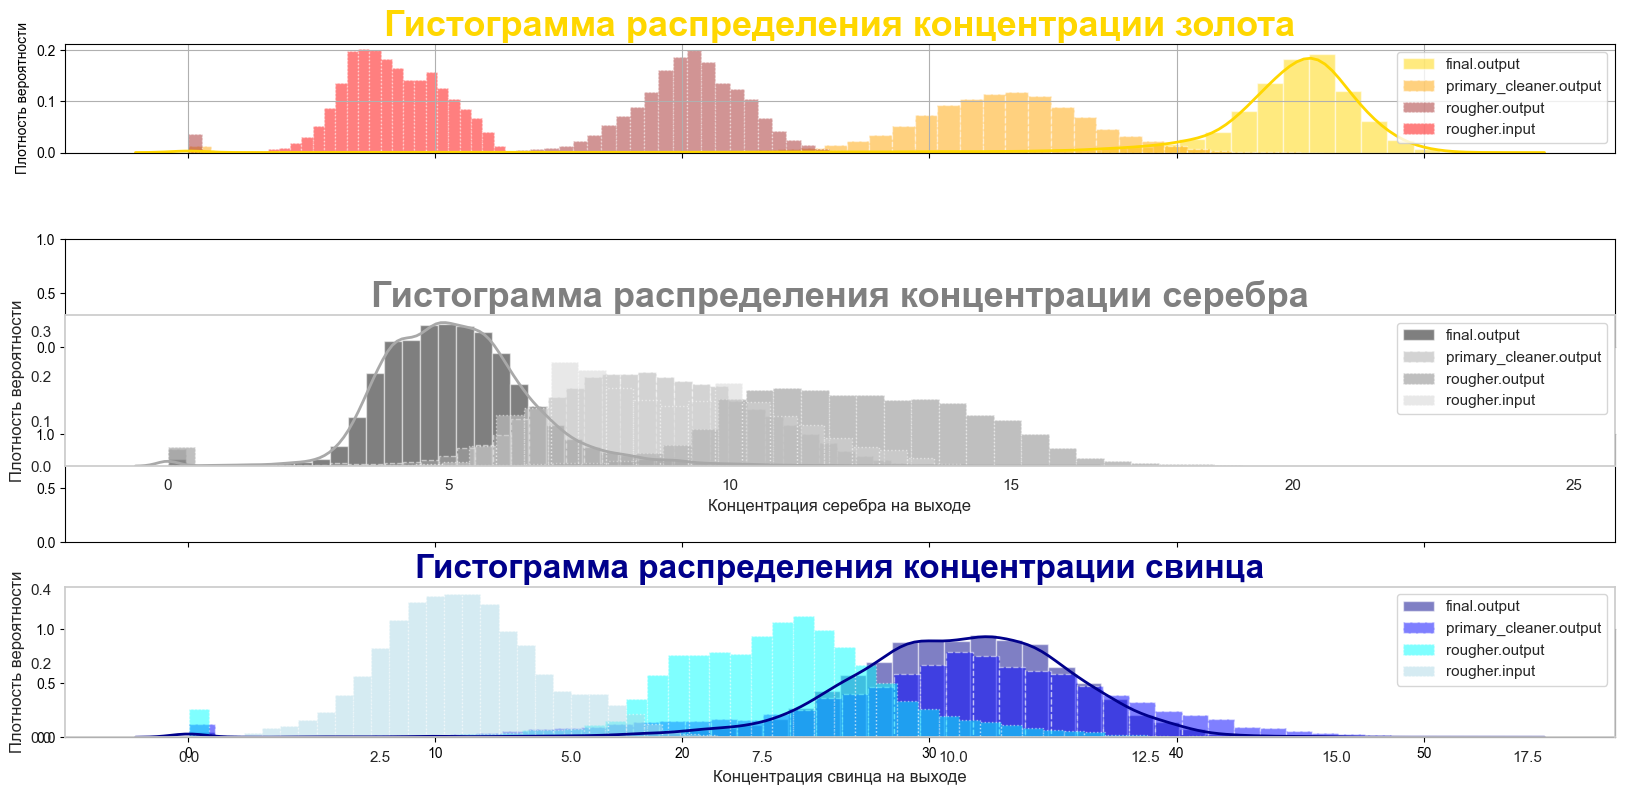

In [13]:
fig, axs = plt.subplots(4, 1, figsize=(20, 9), sharex=True)
plt.subplots_adjust(hspace=0.8) 
sns.set(style="whitegrid")

# 1. Гистограмма для золота
plt.subplot(4, 1, 1)
plt.hist(full_df['final.output.concentrate_au'], 
         bins=50, 
         label='final.output', 
         alpha=0.5, 
         color='gold',
         density=True)
plt.hist(full_df['primary_cleaner.output.concentrate_au'], 
         bins=50, 
         label='primary_cleaner.output', 
         alpha=0.5, 
         color='orange', 
         linestyle='dashed', 
         density=True)
plt.hist(full_df['rougher.output.concentrate_au'], 
         bins=50, 
         label='rougher.output', 
         alpha=0.5, 
         color='brown', 
         linestyle='dotted', 
         density=True)
plt.hist(full_df['rougher.input.feed_au'],
         bins=30,
         label='rougher.input',
         alpha=0.5,
         color='red',
         linestyle='dotted', 
         density=True)
sns.kdeplot(full_df['final.output.concentrate_au'], 
            color='gold', 
            linewidth=2)

plt.xlabel('Концентрация золота на выходе')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма распределения концентрации золота', 
          fontweight='bold', 
          color='gold', 
          fontsize=26)
plt.legend(loc='upper right')
plt.grid()

# 2. Гистограмма для серебра
plt.subplot(3, 1, 2)
plt.hist(full_df['final.output.concentrate_ag'], 
         bins=50, 
         label='final.output', 
         alpha=0.5, 
         color='black', 
         density=True)
plt.hist(full_df['primary_cleaner.output.concentrate_ag'], 
         bins=50, 
         label='primary_cleaner.output', 
         alpha=0.5, color='darkgrey', 
         linestyle='dashed', 
         density=True)
plt.hist(full_df['rougher.output.concentrate_ag'], 
         bins=50, 
         label='rougher.output', 
         alpha=0.5, 
         color='gray', 
         linestyle='dotted', 
         density=True)
plt.hist(full_df['rougher.input.feed_ag'],
         bins=30,
         label='rougher.input',
         alpha=0.5,
         color='lightgray',
         linestyle='dotted', 
         density=True)

sns.kdeplot(full_df['final.output.concentrate_ag'], 
            color='darkgray', 
            linewidth=2)

plt.xlabel('Концентрация серебра на выходе')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма распределения концентрации серебра', 
          fontweight='bold', 
          color='gray', 
          fontsize=26)
plt.legend(loc='upper right')
plt.grid()

# 3. Гистограмма для свинца
plt.subplot(3, 1, 3)
plt.hist(full_df['final.output.concentrate_pb'], 
         bins=50, 
         label='final.output', 
         alpha=0.5, 
         color='darkblue', 
         density=True)
plt.hist(full_df['primary_cleaner.output.concentrate_pb'], 
         bins=50, 
         label='primary_cleaner.output', 
         alpha=0.5, 
         color='blue', 
         linestyle='dashed', 
         density=True)
plt.hist(full_df['rougher.output.concentrate_pb'], 
         bins=50, 
         label='rougher.output', 
         alpha=0.5, 
         color='cyan', 
         linestyle='dotted', 
         density=True)
plt.hist(full_df['rougher.input.feed_pb'],
         bins=30,
         label='rougher.input',
         alpha=0.5,
         color='lightblue',
         linestyle='dotted', 
         density=True)
sns.kdeplot(full_df['final.output.concentrate_pb'], 
            color='darkblue', 
            linewidth=2)

plt.xlabel('Концентрация свинца на выходе')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма распределения концентрации свинца', 
          fontweight='bold', 
          color='darkblue', 
          fontsize=24)
plt.legend(loc='upper right')
plt.grid()
plt.show()

**Промежуточный вывод**

Важно! Концетрация серебра падает после этапа первичной очистки. Возможные причины:
* неверно подобран процесс обогощения (при этом он подходит для золота и свинца)
* разный состав руды на входе
* химические реагенты уменьшают долю серебра
* разбавление другими веществами

Процесс по концентрации золота и свинца выглядит логичным: с каждым следующим технологическим этапом доля содержания металла увеличивается.

Мы также наблюдаем хвосты на всех трёх графиках с значениями признака, близкими к нулю.

Концетрация металлов не может быть нулевая, однако вполне возможно, что среди руды попадаются различные примесные артефакты и это является нормальным явлением. 

Решено оставить распределения без изменений.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class='anchor' id='5.2'></a>
### 5.2. Насколько распределения размеров гранул сырья на обучающей и тестовой выборках различаются?

Взглянем на основные статистические характеристики признака `rougher.input.feed_size` (размер гранул на входе) для тренировочной  и тестовой выборок.

In [14]:
print(train_df['rougher.input.feed_size'].describe())
print(test_df['rougher.input.feed_size'].describe())

count    14149.000000
mean        60.239856
std         23.005310
min          9.659576
25%         48.966751
50%         55.269784
75%         66.007526
max        484.967466
Name: rougher.input.feed_size, dtype: float64
count    5229.000000
mean       55.863978
std        18.914656
min         0.046369
25%        43.911874
50%        50.772729
75%        62.265394
max       392.494040
Name: rougher.input.feed_size, dtype: float64


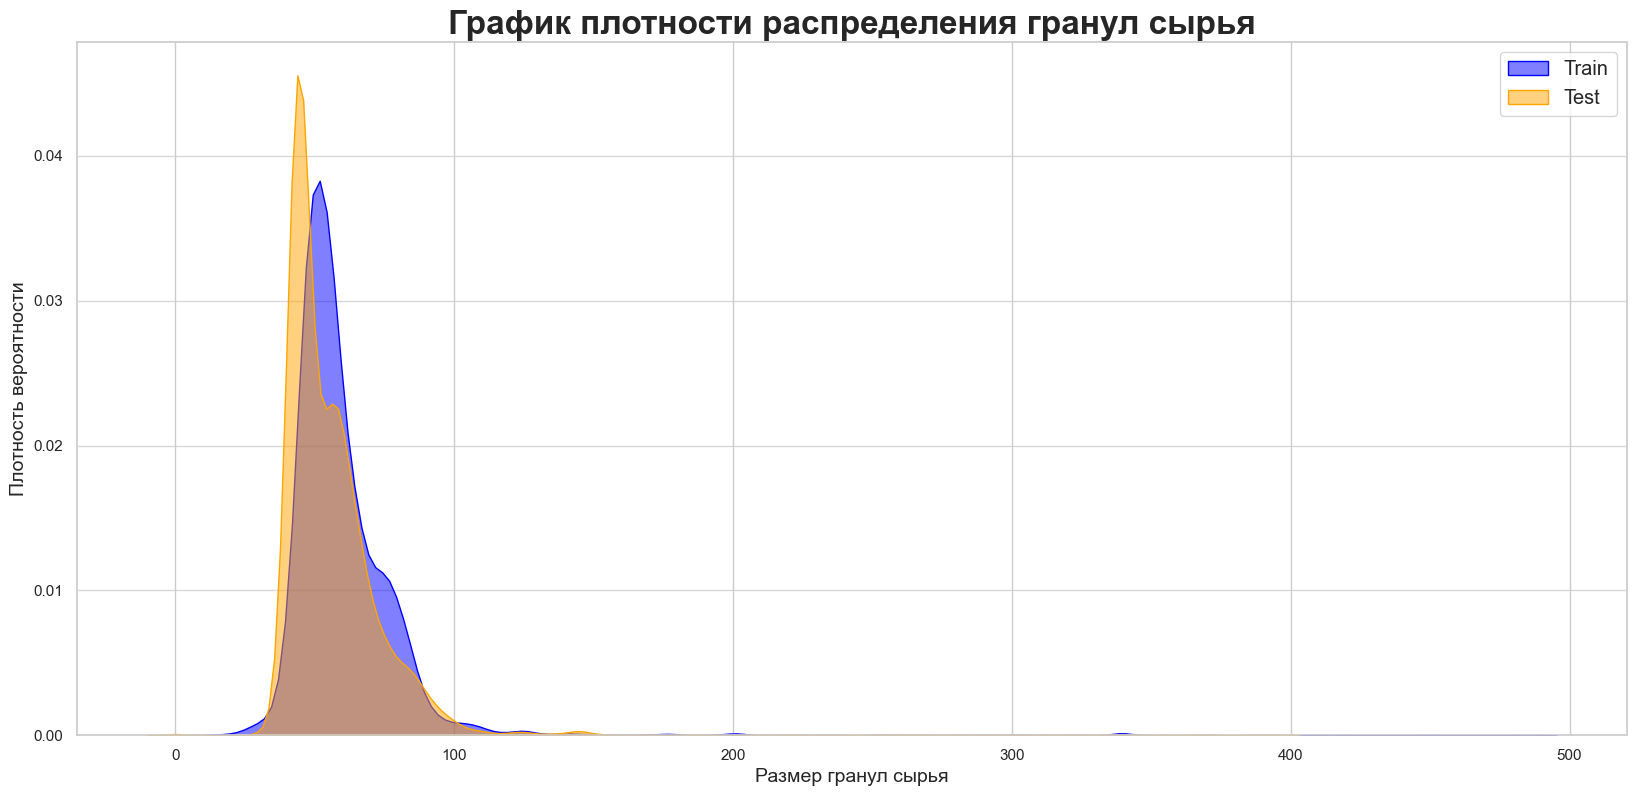

In [15]:
plt.figure(figsize=[20, 9])


sns.kdeplot(train_df['rougher.input.feed_size'], 
             label='Train', 
             color='blue', 
             fill=True, 
             alpha=0.5)


sns.kdeplot(test_df['rougher.input.feed_size'], 
             label='Test', 
             color='orange', 
             fill=True, 
             alpha=0.5)


plt.xlabel("Размер гранул сырья", fontsize=14)
plt.ylabel("Плотность вероятности", fontsize=14)
plt.legend(loc='upper right', fontsize='large')
plt.title("График плотности распределения гранул сырья", 
          fontsize=24, 
          fontweight='bold')
plt.grid(axis='y', alpha=0.75)
plt.show()

Можно наблюдать нетипичные значения признака больше 100. В тренировочной выборке их больше, но и в тестовой они также встречаются. Посчитаем долю возможных выбросов.

In [16]:
print("Тренировочная", len(train_df[train_df['rougher.input.feed_size'] > 100]) / train_df.shape[0])
print("Тестовая", len(test_df[test_df['rougher.input.feed_size'] > 100]) / train_df.shape[0])

Тренировочная 0.02318185030744222
Тестовая 0.005512757085306382


In [17]:
print('Средний размер гранул в обучающей выборке:', train_df['primary_cleaner.input.feed_size'].mean())
print('Средний размер гранул в тестовой выборке:', test_df['primary_cleaner.input.feed_size'].mean())

Средний размер гранул в обучающей выборке: 7.322309906901314
Средний размер гранул в тестовой выборке: 7.271545576079371


**Промежуточный вывод**

Поскольку выборки отличаются по размеру (5529 у тестовой против 1419 у тренировочной), мы использовали график плотности.

Оба распредления являются положительно ассиметричными, при этом основная разница в пиках - на тестовой 50 и на тренировочной 55.

Изредка встречаются гранулы менее 20 и более 100 по размеру. Так, в тестовой выборке их 5.5%, а в тренировочной 2.3%, при этом однородность таких аномалий намекает на то, что такие значения гранул сырья могут существовать.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class='anchor' id='5.3'></a>
### 5.3. Какова суммарная концентрация всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах?

Чтобы ответить на этот вопрос, давайте объединим объём всех известных нам веществ на разных этапах по принципу одного вещества, а затем построим общую распределения на разных этапах.

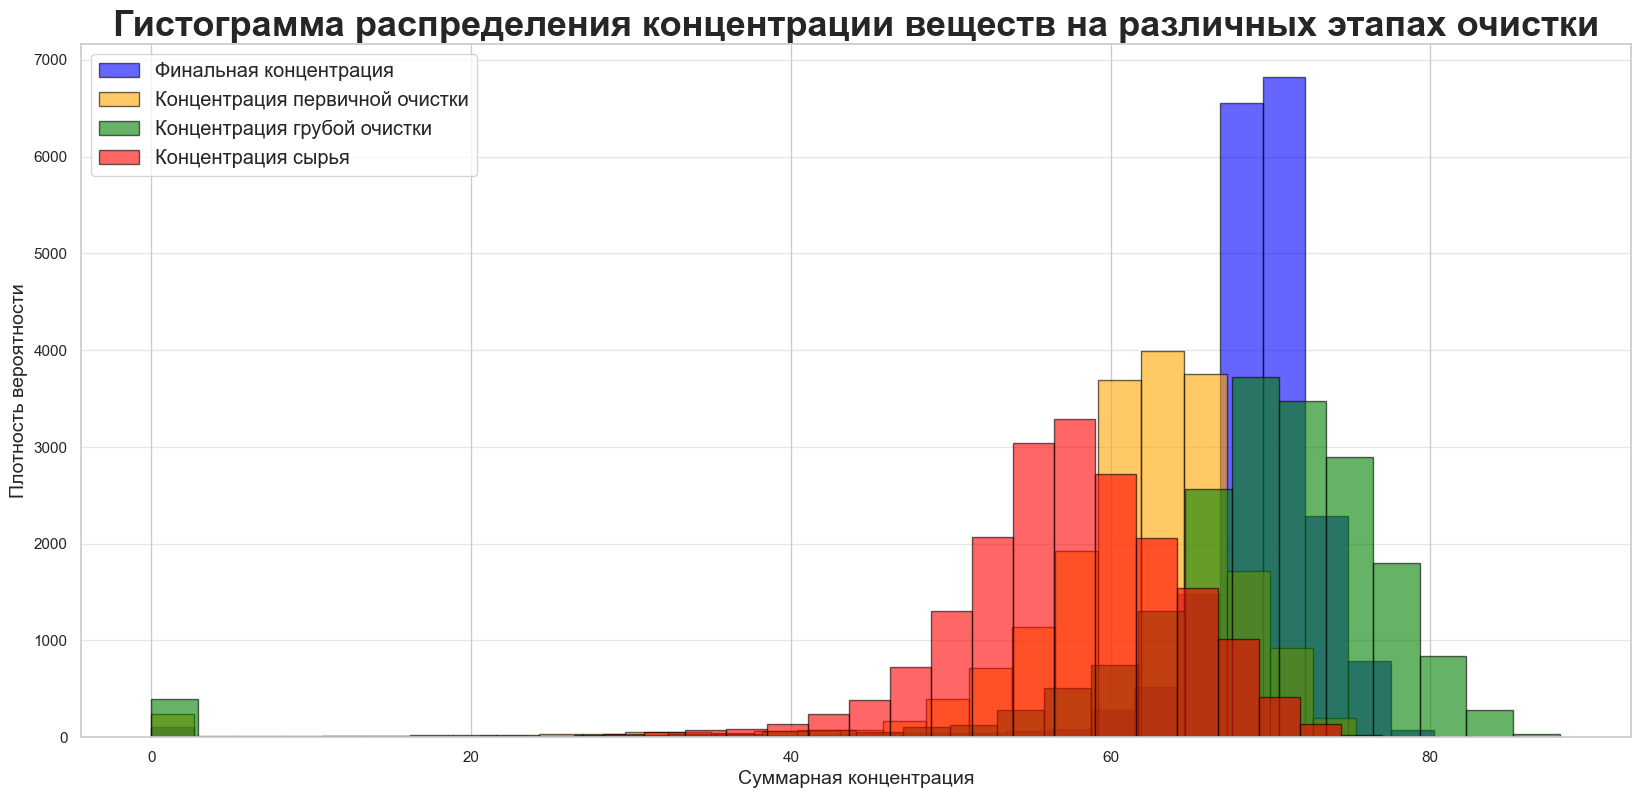

In [18]:
full_df['final.output.concentrate_sum'] = (full_df['final.output.concentrate_au'] + 
                                          full_df['final.output.concentrate_ag'] + 
                                          full_df['final.output.concentrate_pb'] +
                                          full_df['final.output.concentrate_sol'])
full_df['primary_cleaner.output.concentrate_sum'] = (full_df['primary_cleaner.output.concentrate_au'] + 
                                                     full_df['primary_cleaner.output.concentrate_ag'] + 
                                                     full_df['primary_cleaner.output.concentrate_pb'] +
                                                     full_df['primary_cleaner.output.concentrate_sol'])
full_df['rougher.output.concentrate_sum'] = (full_df['rougher.output.concentrate_au'] + 
                                             full_df['rougher.output.concentrate_ag'] + 
                                             full_df['rougher.output.concentrate_pb'] +
                                             full_df['rougher.output.concentrate_sol'])

full_df['rougher.input.feed_sum'] = (full_df['rougher.input.feed_au'] + 
                                     full_df['rougher.input.feed_ag'] + 
                                     full_df['rougher.input.feed_pb'] +
                                     full_df['rougher.input.feed_sol'])

plt.figure(figsize=[20,9])


plt.hist(full_df['final.output.concentrate_sum'], 
         bins=30, 
         label='Финальная концентрация', 
         alpha=0.6, 
         color='blue', 
         edgecolor='black')
plt.hist(full_df['primary_cleaner.output.concentrate_sum'], 
         bins=30, 
         label='Концентрация первичной очистки', 
         alpha=0.6, 
         color='orange', 
         edgecolor='black')
plt.hist(full_df['rougher.output.concentrate_sum'], 
         bins=30, 
         label='Концентрация грубой очистки', 
         alpha=0.6, 
         color='green', 
         edgecolor='black')
plt.hist(full_df['rougher.input.feed_sum'], 
         bins=30, 
         label='Концентрация cырья', 
         alpha=0.6, 
         color='red', 
         edgecolor='black')


plt.xlabel("Суммарная концентрация", fontsize=14)
plt.ylabel("Плотность вероятности", fontsize=14)
plt.legend(loc='upper left', fontsize='large')
plt.title("Гистограмма распределения концентрации веществ на различных этапах очистки", fontsize=26, fontweight='bold')
plt.grid(axis='y', alpha=0.5)
plt.show()

Мы видим несколько аномалий, как и при исследовании вопроса 5.1, однако отдельно по каждому веществу они могут быть, но после прохождения всех этапов их не должно оставаться. В частости, настораживают суммарные концентрации равные нулю - удалим их.

In [19]:
for col in ['rougher.input.feed_sum', 
            'rougher.output.concentrate_sum', 
            'primary_cleaner.output.concentrate_sum', 
            'final.output.concentrate_sum']:
    full_df = full_df.drop(full_df[full_df[col] == 0].index)


    

zero_columns = ['final.output.concentrate_au', 
                'final.output.concentrate_ag', 
                'final.output.concentrate_pb', 
                'final.output.concentrate_sol',
                'primary_cleaner.output.concentrate_au', 
                'primary_cleaner.output.concentrate_ag', 
                'primary_cleaner.output.concentrate_pb', 
                'primary_cleaner.output.concentrate_sol',
                'rougher.output.concentrate_au', 
                'rougher.output.concentrate_ag', 
                'rougher.output.concentrate_pb', 
                'rougher.output.concentrate_sol',
                'rougher.input.feed_au', 
                'rougher.input.feed_ag', 
                'rougher.input.feed_pb', 
                'rougher.input.feed_sol']


train_df = train_df[~(train_df[zero_columns] == 0).any(axis=1)]

**Промежуточный вывод**

Мы видим, что на каждом этапе происходит рост концентрации металлов с 40 до 90. На этапе финального концентрата происходит уменьшение концентрации до дипозона 70-75, при этом количество наблюдений растёт с 4000 до 7000. Это вполне сходится с тем, что должно получить в результате обработки руды.

Были удалены аномалии суммарных концентраций, которые равны нулю.

[_назад к ходу исследования_](#research)

[_назад к содержанию_](#content)

<a class='anchor' id='model'></a>
### 6. Построение, обучение и выбор лучшей модели
* [3.1. Готовим функции метрик качества sMAPE и Итоговое sMAPE](#3.1)
* [3.2. Выделяем целевые признаки и разбиваем выборки](#3.2)
* [3.3. Исследуем модели](#3.3)
* [3.4. Проверяем лучшие модели на тестовой выборке](#3.4)
* [3.5. Сравнение результатов лучшей модели с константной](#3.5)

<a class='anchor' id='3.1'></a>
### 3.1. Готовим функции метрик качества sMAPE и Итоговое sMAPE

Мы будем решать задачу обучения с учетелем, т.к. есть обучающий набор данных и целевой признак известен. Качество моделей измерим с помощью данной заказчиком метрики качества `sMAPE` (симметричное среднее абсолютное процентное отклонение).

Формула имеет следующий вид:

<img src='https://clck.ru/3Ec6ga' alt='Формула для расчёта симметричного среднего абсолютного отклонения'>

Нам необходимо спрогнозировать сразу две величины:

* эффективность обогащения чернового концентрата `rougher.output.recovery`
* эффективность обогащения финального концентрата `final.output.recovery`

Итоговое `sMAPE` рассчитаем по формуле:

<img src='https://pictures.s3.yandex.net/resources/_smape_1576238814.jpg' alt='Формула для расчёта итогового симметричного среднего абсолютного отклонения для чернового и финального концентрата'>

<a class='anchor' id='smape'></a>
Создадим две функции для дальнейших вычислений.

In [20]:
def get_smape(target, predict):
    """
    Вычисляет метрику качества sMAPE (Symmetric Mean Absolute Percentage Error) для количественного признака.
    Формула: sMAPE = (|target - predict| / ((|target| + |predict|) / 2)) * 100

    Параметры:
    ----------
    target: pd.Series
        Серия с истинными значениями (целевыми значениями).
        
    predict: pd.Series
        Серия с предсказанными значениями.

    Возвращает:
    ----------
    float
        Значение метрики sMAPE, выраженное в процентах, 
        которое представляет среднее абсолютное процентное отклонение между истинными и предсказанными значениями. 
        Если отсутствуют значения, то они заполняются нулями.

    Примечание:
    ----------
    Обратите внимание, что для корректной работы функции target и predict должны быть одной длины.

    """
    
    smape = abs(target - predict) / (abs(target + predict) / 2) * 100
    smape.fillna(value=0, inplace=True)
    smape = np.mean(smape)

    return smape


def get_final_smape(target_rouger, predict_rouger, target_final, predict_final):
    """
    Вычисляет итоговую метрику качества sMAPE для двух наборов данных: rouger (черновой концентрат) и final (финальный концентрат).
    Итоговая метрика sMAPE вычисляется как линейная комбинация sMAPE для обеих групп, согласно заданным весам.

    Параметры:
    ----------
    target_rouger: pd.Series
        Серия с истинными значениями (целевыми значениями) для набора данных rouger.

    predict_rouger: pd.Series
        Серия с предсказанными значениями для набора данных rouger.

    target_final: pd.Series
        Серия с истинными значениями (целевыми значениями) для набора данных final.

    predict_final: pd.Series
        Серия с предсказанными значениями для набора данных final.

    Возвращает:
    ----------
    float
        Итоговое значение метрики sMAPE, выраженное в процентах, 
        учитывающее веса для smape_rouger и smape_final.

    Примечание:
    ----------
    Обратите внимание, что для корректной работы функции target и predict должны быть одной длины.
    """
    
    smape_rouger = get_smape(target_rouger, predict_rouger)
    smape_final = get_smape(target_final, predict_final)
    result_smape = 0.25 * smape_rouger + 0.75 * smape_final
    
    return result_smape

[_назад к моделям_](#model)

[_назад к содержанию_](#content)

<a class='anchor' id='3.2'></a>
### 3.2. Выделяем целевые признаки и разбиваем выборки

Теперь необходимо подготовить целевые и остальные признаки объектов перед обучением моделей

Поскольку тестовая выборка доступна, то следует разбить тренировочную на валидационную так, чтобы кол-во объектов в ней примерно совпадало с кол-вом объектом в тестовой выборке.

Наши шаги:

1. Выравнять кол-во столбцов в тренировочной, валидационной и тестовой выборках с помощью разности множеств.
2. Выделить 2 целевых признака и другие признаки для обоих наборов.
3. Разбить тренировочную выборку на тренировочную (70%) и валидацинную (30%).
4. Добавить в тестовую выборку ключевые признаки с помощью объединения по признаку `date` с `full_df` (набор данных имеет все возможные признаки).
5. Удалилить из всех выборок признак `date`, поскольку модели не могут принимать признак в формате `datetime`.

In [21]:
if 'rougher.output.recovery' not in test_df.columns:
    test_df = test_df.merge(full_df[['date', 'rougher.output.recovery', 'final.output.recovery']], 
                            on='date', 
                            how='left')
    print('Ключевые признаки добавлены в test_df')

target_test_rouger = test_df['rougher.output.recovery']
target_test_final = test_df['final.output.recovery']
features_test = test_df.drop(columns=['date', 'rougher.output.recovery', 'final.output.recovery'], axis=1)

print('Размер тестовой выборки', features_test.shape)
print('Размер целевого признака теста (rouger)', target_test_rouger.shape)
print('Размер целевого признака теста (final)', target_test_final.shape)

Ключевые признаки добавлены в test_df
Размер тестовой выборки (5229, 56)
Размер целевого признака теста (rouger) (5229,)
Размер целевого признака теста (final) (5229,)


In [22]:
if 'date' in train_df.columns:
    difference_columns = set(train_df.columns).difference(test_df.columns).union(set(['date']))
    train_df = train_df.drop(columns=difference_columns, axis=1)

In [23]:
target_columns = train_df[['rougher.output.recovery', 'final.output.recovery']]
features_train = train_df.drop(columns=['rougher.output.recovery', 'final.output.recovery'], axis=1)

features_train, features_valid, targets_train, targets_valid = tts(features_train, 
                                                                   target_columns, 
                                                                   test_size=0.3, 
                                                                   random_state=111)

target_train_rouger = targets_train['rougher.output.recovery']
target_train_final = targets_train['final.output.recovery']

target_valid_rouger = targets_valid['rougher.output.recovery']
target_valid_final = targets_valid['final.output.recovery']

print("Размер тренировочной выборки:", features_train.shape)
print("Размер целевого признака тренировки (rougher):", target_train_rouger.shape)
print("Размер целевого признака тренировки  (final):", target_train_final.shape)
print()

print("Размер валидационной выборки:", features_valid.shape)
print("Размер целевого признака валидации (rouger):", target_valid_rouger.shape)
print("Размер целевого признака валидации (final):", target_valid_final.shape)

Размер тренировочной выборки: (9601, 56)
Размер целевого признака тренировки (rougher): (9601,)
Размер целевого признака тренировки  (final): (9601,)

Размер валидационной выборки: (4115, 56)
Размер целевого признака валидации (rouger): (4115,)
Размер целевого признака валидации (final): (4115,)


[_назад к моделям_](#model)

[_назад к содержанию_](#content)

<a class='anchor' id='3.3'></a>
### 3.3. Исследуем модели

Воспользуемся алгоритмом - деревом решений регрессии `DecisionTreeRegressor`.

Для того, чтобы найти наилучший результат, будем менять гипермараметр `max_depth` (максимальная глубина дерева) алгоритма при создании модели в цикле, а правильность определять по метрике качества `sMAPE`.

In [24]:
best_model_tree_rouger = None
best_result_tree_rouger = 100

for depth in range(1, 30, 2):
    model = DecisionTreeRegressor(max_depth=depth, random_state=111)
    model.fit(features_train, target_train_rouger)
    predictions_valid_tree_rouger = model.predict(features_valid)
    
    curr_smape = get_smape(target_valid_rouger, predictions_valid_tree_rouger)
    
    if curr_smape < best_result_tree_rouger:
        best_model_tree_rouger = model
        best_result_tree_rouger = curr_smape.round(2)
        
print("sMAPE наилучшей модели для чернового концетрата на валидационной выборке:", 
      best_result_tree_rouger, 
      "Параметры модели:", 
      best_model_tree_rouger, sep='\n')

sMAPE наилучшей модели для чернового концетрата на валидационной выборке:
3.71
Параметры модели:
DecisionTreeRegressor(max_depth=15, random_state=111)


In [25]:
best_model_tree_final = None
best_result_tree_final= 100

for depth in range(1, 30, 2):
    model = DecisionTreeRegressor(max_depth=depth, random_state=111)
    model.fit(features_train, target_train_final)
    predictions_valid_tree_final = model.predict(features_valid)
    
    curr_smape = get_smape(target_valid_final, predictions_valid_tree_final)
    
    if curr_smape < best_result_tree_final:
        best_model_tree_final = model
        best_result_tree_final = curr_smape.round(2)
        
print("sMAPE наилучшей модели для финального концетрата на валидационной выборке:", 
      best_result_tree_final, 
      "Параметры модели:", 
      best_model_tree_final, sep='\n')

sMAPE наилучшей модели для финального концетрата на валидационной выборке:
7.49
Параметры модели:
DecisionTreeRegressor(max_depth=11, random_state=111)


In [26]:
final_smape_tree_regressor = get_final_smape(target_valid_rouger, 
                                             predictions_valid_tree_rouger, 
                                             target_valid_final, 
                                             predictions_valid_tree_final).round(2)

final_smape_tree_regressor

np.float64(7.17)

Текущая погрешность метрики качества `Итоговый sMAPE` на отличном уровне 7.17%

Проверим, сможем ли мы добиться улучшений с помощью другого алгоритма - случайного леса в регрессии `RandomForestRegressor`. 

Примечание: диапозоны для кол-ва наблюдателей и глубины были скорректированы в ходе тестов для ускорения выполнения ячеек.

In [27]:
best_model_forest_rouger = None
best_result_forest_rouger = 100

for estimator in range(1, 3):
    for depth in range(9, 13):
        model = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=111, n_jobs=-1)
        model.fit(features_train, target_train_rouger)
        predictions_valid_forest_rouger = model.predict(features_valid)
        
        curr_smape = get_smape(target_valid_rouger, predictions_valid_forest_rouger)
    
        if curr_smape < best_result_forest_rouger:
            best_model_forest_rouger = model
            best_result_forest_rouger = curr_smape.round(2)
        
print("sMAPE наилучшей модели для чернового концетрата на валидационной выборке:", 
      best_result_forest_rouger, 
      "Параметры модели:", 
      best_model_forest_rouger, sep='\n')

sMAPE наилучшей модели для чернового концетрата на валидационной выборке:
3.58
Параметры модели:
RandomForestRegressor(max_depth=12, n_estimators=2, n_jobs=-1, random_state=111)


In [28]:
best_model_forest_final = None
best_result_forest_final = 100

for estimator in (40, 51, 10):
    for depth in (10, 12):
        model = RandomForestRegressor(n_estimators=estimator, max_depth=depth, random_state=111, n_jobs=-1)
        model.fit(features_train, target_train_final)
        predictions_valid_forest_final = model.predict(features_valid)
        
        curr_smape = get_smape(target_valid_final, predictions_valid_forest_final)
    
        if curr_smape < best_result_forest_final:
            best_model_forest_final = model
            best_result_forest_final = curr_smape.round(2)
            
            
print("sMAPE наилучшей модели для финального концетрата на валидационной выборке:", 
      best_result_forest_final, 
      "Параметры модели:",
      best_model_forest_final, sep='\n')

sMAPE наилучшей модели для финального концетрата на валидационной выборке:
6.36
Параметры модели:
RandomForestRegressor(max_depth=12, n_estimators=51, n_jobs=-1,
                      random_state=111)


In [29]:
final_smape_forest_regressor = get_final_smape(target_valid_rouger, 
                                             predictions_valid_forest_rouger, 
                                             target_valid_final, 
                                             predictions_valid_forest_final).round(2)

final_smape_forest_regressor

np.float64(5.83)

Удалось уменьшить погрешность метрики качества `Итоговый sMAPE` c 7.17% до 5.83%.

Наконец, используем ещё один алгоритм - линейную регрессию `LinearRegression`.

In [30]:
best_model_linear_rouger = None
best_model_linear_final = None

best_model_linear_rouger = LinearRegression()
best_model_linear_rouger.fit(features_train, target_train_rouger)
predictions_valid_linear_rouger = best_model_linear_rouger.predict(features_valid)
smape_linear_rouger = get_smape(target_valid_rouger, predictions_valid_linear_rouger)

best_model_linear_final = LinearRegression()
best_model_linear_final.fit(features_train, target_train_final)
predictions_valid_linear_final = best_model_linear_final.predict(features_valid)
smape_linear_final = get_smape(target_valid_final, predictions_valid_linear_final)

final_smape_linear_regressor = get_final_smape(target_valid_rouger, 
                                             predictions_valid_linear_rouger, 
                                             target_valid_final, 
                                             predictions_valid_linear_final).round(2)

print("sMAPE наилучшей модели для чернового концетрата на валидационной выборке:", smape_linear_rouger)

print("sMAPE наилучшей модели для финального концетрата на валидационной выборке:", smape_linear_final)

print("Итоговый sMAPE:", final_smape_linear_regressor)

sMAPE наилучшей модели для чернового концетрата на валидационной выборке: 4.60149079554297
sMAPE наилучшей модели для финального концетрата на валидационной выборке: 8.103690729731511
Итоговый sMAPE: 7.23


Алгоритм линейной регрессии показал самое высокое отклоение от нормы.

In [31]:
final_smape_tree_regressor = get_final_smape(target_valid_rouger, 
                                              best_model_tree_rouger.predict(features_valid), 
                                              target_valid_final, 
                                              best_model_tree_final.predict(features_valid)).round(2)

final_smape_forest_regressor = get_final_smape(target_valid_rouger, 
                                               best_model_forest_rouger.predict(features_valid), 
                                               target_valid_final, 
                                               best_model_forest_final.predict(features_valid)).round(2)

final_smape_linear_regressor = get_final_smape(target_valid_rouger, 
                                               best_model_linear_rouger.predict(features_valid), 
                                               target_valid_final, 
                                               best_model_linear_final.predict(features_valid)).round(2)

best_smape_valid = [final_smape_tree_regressor, final_smape_forest_regressor, final_smape_linear_regressor]
best_index = best_smape_valid.index(min(best_smape_valid))

best_valid_smape = best_smape_valid[best_index]
production_model = ["Tree Regressor", "Forest Regressor", "Linear Regressor"][best_index]

print("Лучшая модель по итоговому sMAPE для валидационной выборки:", best_valid_smape)
print("Выбранная модель для продакшн:", production_model)

Лучшая модель по итоговому sMAPE для валидационной выборки: 5.67
Выбранная модель для продакшн: Forest Regressor


Таким образом, лучшей моделью является классификатор деревьев решений.

[_назад к моделям_](#model)

[_назад к содержанию_](#content)

<a class='anchor' id='3.4'></a>
### 3.4. Проверяем лучшие модели на тестовой выборке

In [32]:
if production_model == "Tree Regressor":
    predictions_test_best = best_model_tree_rouger.predict(features_test)
    predictions_test_final_best = best_model_tree_final.predict(features_test)
elif production_model == "Forest Regressor":
    predictions_test_best = best_model_forest_rouger.predict(features_test)
    predictions_test_final_best = best_model_forest_final.predict(features_test)
elif production_model == "Linear Regressor":
    predictions_test_best = best_model_linear_rouger.predict(features_test)
    predictions_test_final_best = best_model_linear_final.predict(features_test)

test_smape_best = get_final_smape(target_test_rouger, 
                                    predictions_test_best, 
                                    target_test_final, 
                                    predictions_test_final_best).round(2)

print("sMAPE для тестовой выборки лучшей модели по валидационной выборке:", test_smape_best)

production_model = best_model_forest_final

model_filename = 'production_forest_model.pkl'
# joblib.dump(production_model, model_filename)

sMAPE для тестовой выборки лучшей модели по валидационной выборке: 7.76


['production_forest_model.pkl']

[_назад к моделям_](#model)

[_назад к содержанию_](#content)

<a class='anchor' id='3.5'></a>
### 3.5. Сравнение результатов лучшей модели с константной

In [33]:
dummy_model = DummyRegressor(strategy="median")
dummy_model.fit(features_train, target_train_rouger)
dummy_predictions_rouger = dummy_model.predict(features_test)
dummy_predictions_final = dummy_model.predict(features_test)

dummy_smape = get_final_smape(target_test_rouger, 
                               dummy_predictions_rouger, 
                               target_test_final, 
                               dummy_predictions_final).round(2)

print("sMAPE для Dummy Regressor:", dummy_smape)
print("sMAPE для выбранной модели:", test_smape_best)

if test_smape_best < dummy_smape:
    print("Наша модель лучше")
else:
    print("Константная модель лучше")

sMAPE для Dummy Regressor: 17.06
sMAPE для выбранной модели: 7.76
Наша модель лучше


[_назад к моделям_](#model)

[_назад к содержанию_](#content)

<a class='anchor' id='result'></a>
### 7. Результаты исследования

<div class="alert alert-info">
<b> Модели прогнозирования </div>
    
Перед обучением, тренировкой и выбором модели были проверенны все признаки эффективности обогощения с помощью метрики качества MAE. Результат - средняя абсолютная ошибка околонулевая, что говорит о достоверности количественных паметров признака `recovery`.

В ходе работы над проектом мы обучили шесть моделей, подходящих для задач регрессии, на тренировочной выборке с целью найти лучшие показателе метрики качества `Итоговое sMAPE` сначала на валидационной, а затем на тестовой выборке. 

Модели прогнозируют эффективность обогощения золотом руды в черновом и финальном концетрате и помогут снизить издержки для поиска месторождений.

Результаты погрешности обученных моделей по метрике `Итоговое sMAPE` на валидационной выборке:

* `DecisionTreeRegressor` - 7.17%
* `RandomForestRegressor` - 5.83%
* `LinearRegression` - 7.23%
    
Результаты погрешности лучшей модели по метрике `Итоговое sMAPE` на тестовой выборке:
* `RandomForestRegressor` - 7.76%
    
Проверку на адекватность лучшая модель прошла.

<div class="alert alert-info">
<b> Готовая модель </div>
    
* Для загрузки модели используйте следующий код:
    
```
import joblib
loaded_model = joblib.load(model_filename)
```

* Или скачайте итоговую модель по ссылке:

https://github.com/e6ton1set/yandex-practicum/blob/master/projects/models/production_forest_model.pkl
    
* Проверить метрику качества `sMAPE` или `Итоговое sMAPE` можно с помощью [_функции_](#smape)

### Задачи исследования

<div class="alert alert-info">
<b> 1. Как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки? </div>

* Концетрация золота и свинца растёт с каждым этапом (флотация, первичная очистка и финальный концентрат) ~ от 3 до 45 и ~ от 1 до 11 соответственно
* Концетрация серебра падает на этапе первичной очистки ~ от 15 до диапозона от 3 до 7

Среди всех концетраций наблюдаются хвосты со значениями, близкими к нулю.

<div class="alert alert-info">
<b> 2. Насколько распределения размеров гранул сырья на обучающей и тестовой выборках различаются (при сильных отличиях оценка модели будет неправильной)?</div>
    
Оба распредления являются положительно ассиметричными с основным размером гранул от 25 до 75 у.е. 
    
Небольшая часть значений признаков находится выше 100 и ниже 20:
    
* для тренировочной выборки - доля ~2.3%
* для тестовой выборки - доля ~5.5%
    
Медианный размер находится на уровне 55 для тренировочной и 50 для тестовой выборок.
    
<div class="alert alert-info">
<b> 3. Какова суммарная концентрация всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах?</div>
    
На каждом этапе происходит рост концентрации металлов ~ от 40 до 90. На этапе финального концентрата происходит уменьшение концентрации до дипозона 70-75, при этом количество наблюдений растёт с 4000 до 7000. Это вполне сходится с тем, что должно получить в результате обработки руды.

<div class="alert alert-info anchor" style="color:green" id="recommendation">
<b> Рекомендации </div>
    
Для уменьшения погрешности предсказаний (метрика `Итоговое sMAPE`) требуется:
* получить консультацию эксперта по реалистичности концентрации металов в диапозоне от 1 до 5
* получить консультацию эксперта по реалистичности размера гранул менее 20 и более 100
    
**Важно!**

Возможные причины уменьшения концентрации серебра на этапе первичной очистки:

1. Неверно подобран процесс обогощения (при этом он подходит для золота и свинца)
2. Разный состав руды на входе
3. Химические реагенты уменьшают долю серебра
4. Разбавление другими веществами
    
Необходимо передать информацию эксперту.
    
[назад к содержанию](#content)

<a class='anchor' id='check'></a>
### 8. Чек-лист готовности проекта

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке выполнения
- [x]  Выполнен шаг 1: данные подготовлены
    - [x]  Проверена формула вычисления эффективности обогащения
    - [x]  Проанализированы признаки, недоступные в тестовой выборке
    - [x]  Проведена предобработка данных
- [x]  Выполнен шаг 2: данные проанализированы
    - [x]  Исследовано изменение концентрации элементов на каждом этапе
    - [x]  Проанализированы распределения размеров гранул на обучающей и тестовой выборках
    - [x]  Исследованы суммарные концентрации
- [x]  Выполнен шаг 3: построена модель прогнозирования
    - [x]  Написана функция для вычисления итогового *sMAPE*
    - [x]  Обучено и проверено несколько моделей
    - [x]  Выбрана лучшая модель, её качество проверено на тестовой выборке


[_назад к содержанию_](#content)